<a href="https://colab.research.google.com/github/ThomasAlbin/Space-Science-With-Python/blob/main/2026/02_SPICE_Earths_position.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPICE Lecture 02: Earth's Position & Kernel Inspection

In this notebook we explore **how to inspect SPICE kernels** before using them — a critical first step in any SPICE-based analysis. Two kernel types are at the core of planetary science computations:

- **PCK (Planetary Constants Kernel)** — text kernel (`.tpc`) storing physical and rotational constants for solar system bodies: radii, pole orientation angles (`POLE_RA`, `POLE_DEC`), and prime-meridian rotation rate (`PM`).
- **SPK (Spacecraft & Planet Kernel)** — binary kernel (`.bsp`) storing ephemeris data: positions and velocities of bodies as a function of time.

## Kernel inspection & understanding

In [45]:
import re
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spiceypy as spice

plt.style.use('dark_background')
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 11

In [46]:
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

kernels = {
    "naif0012.tls": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls",
    "pck00010.tpc": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00010.tpc",
    "gm_de440.tpc": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc",
    "de432s.bsp":   "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de432s.bsp"
}

for name, url in kernels.items():
    path = data_dir / name
    if not path.exists():
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"{name} already exists.")

for name in kernels:
    spice.furnsh(str(data_dir / name))

naif0012.tls already exists.
pck00010.tpc already exists.
gm_de440.tpc already exists.
de432s.bsp already exists.


In [79]:
# Alternative path: using curl or wget

# Leapseconds
!curl https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls --create-dirs -o ../data/naif0012.tls

# SPK
!curl https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de432s.bsp --create-dirs -o ../data/de432s.bsp

# PCK
!curl https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00010.tpc --create-dirs -o ../data/pck00010.tpc
!curl https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc --create-dirs -o ../data/gm_de440.tpc

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5257  100  5257    0     0   7721      0 --:--:-- --:--:-- --:--:--  7730
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 10.3M  100 10.3M    0     0  4100k      0  0:00:02  0:00:02 --:--:-- 4100k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  123k  100  123k    0     0   106k      0  0:00:01  0:00:01 --:--:--  106k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12406  100 12406    0     0  18546      0 --:--:-- --:--:-- --:--:-- 18571


---
## 1. PCK Kernel Inspection — `pck00010.tpc`

The PCK is a **text kernel** whose contents are loaded into SPICE's internal *kernel pool* — a key-value store. Every variable follows the naming convention `BODY<id>_<property>`. We use `gnpool()` to search the pool with a wildcard pattern and collect all matching variable names.

In [47]:
# ── 1a. Collect all BODY* variables from the kernel pool ─────────────────────
all_vars = spice.gnpool('BODY*', 0, 2000, 100)
print(f"Total BODY* variables in pool: {len(all_vars)}")

# ── 1b. Parse body IDs and property types ────────────────────────────────────
body_props = {}  # {body_id: [prop1, prop2, ...]}
for var in all_vars:
    m = re.match(r'BODY(-?\d+)_(.*)', var)
    if m:
        bid, prop = int(m.group(1)), m.group(2)
        body_props.setdefault(bid, []).append(prop)

# Resolve NAIF IDs to human-readable names (fall back to 'UNKNOWN')
def id_to_name(bid):
    try:
        return spice.bodc2n(bid)
    except Exception:
        return 'UNKNOWN'

print(f"Unique bodies with constants: {len(body_props)}")

# ── 1c. Build a DataFrame with one row per body ───────────────────────────────
df_pck = pd.DataFrame([
    {
        'NAIF ID':    bid,
        'Name':       id_to_name(bid),
        'Properties': ', '.join(sorted(body_props[bid])),
    }
    for bid in sorted(body_props)
])

df_pck

Total BODY* variables in pool: 626
Unique bodies with constants: 152


,NAIF ID,Name,Properties
0,0,SOLAR SYSTEM BARYCENTER,GMLIST
1,1,MERCURY BARYCENTER,"GM, NUT_PREC_ANGLES"
2,2,VENUS BARYCENTER,GM
3,3,EARTH BARYCENTER,"GM, NUT_PREC_ANGLES"
4,4,MARS BARYCENTER,"GM, NUT_PREC_ANGLES"
...,...,...,...
147,920469705,UNKNOWN,GM
148,920612095,UNKNOWN,GM
149,920612687,UNKNOWN,GM
150,953031823,UNKNOWN,GM


### 1d. Physical Radii for Key Solar System Bodies

The `RADII` variable holds three values: the equatorial semi-major axis $a$, equatorial semi-minor axis $b$, and polar radius $c$ (all in **km**). From these we can derive:
- **Mean radius**: $\bar{r} = (a + b + c)/3$
- **Flattening**: $f = (a - c)/a$ (Earth is notably oblate, $f \approx 1/298$)

In [48]:
# Bodies for which we want to show radii (NAIF IDs of planets + Moon + Sun)
RADII_BODIES = {
    10:  'Sun',
    199: 'Mercury',
    299: 'Venus',
    399: 'Earth',
    301: 'Moon',
    499: 'Mars',
    599: 'Jupiter',
    699: 'Saturn',
    799: 'Uranus',
    899: 'Neptune',
    999: 'Pluto',
}

rows = []
for bid, label in RADII_BODIES.items():
    if bid in body_props and 'RADII' in body_props[bid]:
        _, (a, b, c) = spice.bodvcd(bid, 'RADII', 3)
        mean_r = (a + b + c) / 3.0
        f      = (a - c) / a if a > 0 else 0.0
        rows.append({
            'Body':         label,
            'a (km)':       round(a, 3),
            'b (km)':       round(b, 3),
            'c (km)':       round(c, 3),
            'Mean r (km)':  round(mean_r, 3),
            'Flattening f': round(f, 6),
        })

df_radii = pd.DataFrame(rows)
radii_data = {r['Body']: (r['a (km)'], r['b (km)'], r['c (km)']) for r in rows}

df_radii

,Body,a (km),b (km),c (km),Mean r (km),Flattening f
0,Sun,696000.000,696000.000,696000.000,696000.000,0.000000
1,Mercury,2439.700,2439.700,2439.700,2439.700,0.000000
2,Venus,6051.800,6051.800,6051.800,6051.800,0.000000
3,Earth,6378.137,6378.137,6356.752,6371.008,0.003353
4,Moon,1737.400,1737.400,1737.400,1737.400,0.000000
5,Mars,3396.190,3396.190,3376.200,3389.527,0.005886
6,Jupiter,71492.000,71492.000,66854.000,69946.000,0.064874
7,Saturn,60268.000,60268.000,54364.000,58300.000,0.097962
8,Uranus,25559.000,25559.000,24973.000,25363.667,0.022927
9,Neptune,24764.000,24764.000,24341.000,24623.000,0.017081


In [ ]:
# Alternative Way: Print in a formatted table
# Bodies for which we want to show radii (NAIF IDs of planets + Moon + Sun)
RADII_BODIES = {
    10:  'Sun',
    199: 'Mercury',
    299: 'Venus',
    399: 'Earth',
    301: 'Moon',
    499: 'Mars',
    599: 'Jupiter',
    699: 'Saturn',
    799: 'Uranus',
    899: 'Neptune',
    999: 'Pluto',
}

radii_data = {}
for bid, label in RADII_BODIES.items():
    if bid in body_props and 'RADII' in body_props[bid]:
        vals = spice.bodvcd(bid, 'RADII', 3)
        radii_data[label] = vals[1]   # bodvcd returns (n, values)

print(f"{'Body':<12}  {'a (km)':>12}  {'b (km)':>12}  {'c (km)':>12}  "
      f"{'Mean r (km)':>14}  {'Flattening f':>14}")
print("-" * 85)
for label, (a, b, c) in radii_data.items():
    mean_r = (a + b + c) / 3.0
    f      = (a - c) / a if a > 0 else 0.0
    print(f"{label:<12}  {a:>12.3f}  {b:>12.3f}  {c:>12.3f}  {mean_r:>14.3f}  {f:>14.6f}")

Body                a (km)        b (km)        c (km)     Mean r (km)    Flattening f
-------------------------------------------------------------------------------------
Sun             696000.000    696000.000    696000.000      696000.000        0.000000
Mercury           2439.700      2439.700      2439.700        2439.700        0.000000
Venus             6051.800      6051.800      6051.800        6051.800        0.000000
Earth             6378.137      6378.137      6356.752        6371.008        0.003353
Moon              1737.400      1737.400      1737.400        1737.400        0.000000
Mars              3396.190      3396.190      3376.200        3389.527        0.005886
Jupiter          71492.000     71492.000     66854.000       69946.000        0.064874
Saturn           60268.000     60268.000     54364.000       58300.000        0.097962
Uranus           25559.000     25559.000     24973.000       25363.667        0.022927
Neptune          24764.000     24764.000    

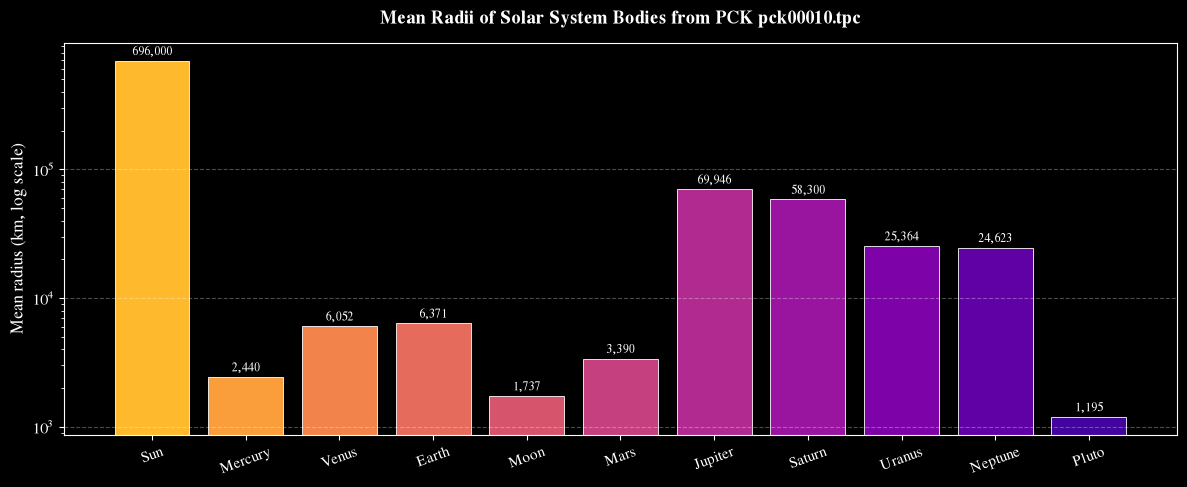

In [53]:
# ── Visualise mean radii (log scale) ─────────────────────────────────────────
labels = list(radii_data.keys())
means  = [(sum(v) / 3) for v in radii_data.values()]

colors = plt.cm.plasma_r(np.linspace(0.15, 0.9, len(labels)))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, means, color=colors, edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.05,
            f"{val:,.0f}",
            ha='center', va='bottom', fontsize=8.5, color='white')

ax.set_yscale('log')
ax.set_ylabel("Mean radius (km, log scale)", fontsize=12)
ax.set_title("Mean Radii of Solar System Bodies from PCK pck00010.tpc",
             fontsize=13, fontweight='bold', pad=14)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

---
## 2. SPK Kernel Inspection — `de432s.bsp`

`de432s.bsp` is NASA JPL's **DE432s** planetary ephemeris in SPICE binary format. The `s` suffix stands for *short*, meaning it covers a reduced time span (1950–2050) compared to the full DE432 (1550–2650). It encodes the positions and velocities of the major solar system bodies relative to the Solar System Barycenter.

Two SPICE functions reveal the contents of an SPK without loading all data into memory:
- `spice.spkobj(file)` — returns the set of NAIF IDs present in the file.
- `spice.spkcov(file, id)` — returns a **SPICE window** (list of time intervals) giving the exact coverage for that object.

In [50]:
SPK_FILE = str(data_dir / 'de432s.bsp')

# ── 2a. List all objects in the SPK ──────────────────────────────────────────
obj_ids = list(spice.spkobj(SPK_FILE))
print(f"Objects covered in de432s.bsp: {len(obj_ids)}")

# ── 2b. Retrieve coverage windows and convert to UTC ─────────────────────────
coverage = []
for oid in sorted(obj_ids):
    cov = spice.spkcov(SPK_FILE, oid)
    for i in range(spice.wncard(cov)):
        et_start, et_end = spice.wnfetd(cov, i)
        coverage.append({
            'NAIF ID':        oid,
            'Name':           id_to_name(oid),
            'Coverage Start': spice.et2utc(et_start, 'ISOC', 0),
            'Coverage End':   spice.et2utc(et_end,   'ISOC', 0),
            'Span (days)':    round((et_end - et_start) / 86400.0, 1),
        })

df_spk = pd.DataFrame(coverage)
df_spk

Objects covered in de432s.bsp: 14


,NAIF ID,Name,Coverage Start,Coverage End,Span (days)
0,1,MERCURY BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
1,2,VENUS BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
2,3,EARTH BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
3,4,MARS BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
4,5,JUPITER BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
5,6,SATURN BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
6,7,URANUS BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
7,8,NEPTUNE BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
8,9,PLUTO BARYCENTER,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0
9,10,SUN,1949-12-13T23:59:19,2050-01-01T23:58:51,36544.0


## Earth's position and velocity

In [65]:
# Let's compute the state vector of Earth w.r.t. the Sun for "NOW" ... this very point in time
import datetime
datetime_now = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
et_now = spice.str2et(datetime_now)
earth_state_wrt_sun, earth_sun_light_time = spice.spkgeo(targ=399,
                                                         et=et_now,
                                                         ref='ECLIPJ2000',
                                                         obs=10)

# Print x, y, z, vx, vy, vz in a formatted way
print(f"State vector of Earth w.r.t. Sun at {datetime_now} (ET):")
print(f"  Position (km): x={earth_state_wrt_sun[0]:.3f}, y={earth_state_wrt_sun[1]:.3f}, z={earth_state_wrt_sun[2]:.3f}")
print(f"  Velocity  (km/s): vx={earth_state_wrt_sun[3]:.1f}, vy={earth_state_wrt_sun[4]:.1f}, vz={earth_state_wrt_sun[5]:.6f}")

State vector of Earth w.r.t. Sun at 2026-06-14 16:21:23 (ET):
  Position (km): x=-17821287.530, y=-150894151.596, z=8785.607
  Velocity  (km/s): vx=29.1, vy=-3.6, vz=0.000358


In [67]:
# Determine 1 AU from SPICE
one_au = spice.convrt(1.0, 'AU', 'KM')
print(f"1 AU in kilometers (from SPICE): {one_au:.3f} km")

1 AU in kilometers (from SPICE): 149597870.614 km


In [68]:
# Compute the current distance from Earth to Sun in AU
distance_km = np.linalg.norm(earth_state_wrt_sun[:3])
distance_au = distance_km / one_au
print(f"Current Earth-Sun distance: {distance_km:.3f} km ({distance_au:.3f} AU)")

Current Earth-Sun distance: 151942895.037 km (1.016 AU)


In [73]:
# We compute the distance between Earth and Sun... but... is there a difference between sun and SSB?
sun_state_wrt_ssb, sun_ssb_light_time = spice.spkgeo(targ=10,
                                                        et=et_now,
                                                        ref='ECLIPJ2000',
                                                        obs=0)
sun_ssb_distance_km = np.linalg.norm(sun_state_wrt_ssb[:3])
sun_ssb_distance_au = sun_ssb_distance_km / one_au
print(f"Current Sun-SSB distance: {sun_ssb_distance_km:.3f} km ({sun_ssb_distance_au:.3f} AU)")

# Let's compute it in "Solar Radii" as well
sun_radius_km = radii_data['Sun'][0]  # a (km)
distance_solar_radii = sun_ssb_distance_km / sun_radius_km
print(f"Current Earth-Sun distance: {distance_solar_radii:.3f} solar radii")

Current Sun-SSB distance: 853762.494 km (0.006 AU)
Current Earth-Sun distance: 1.227 solar radii


In [69]:
# Compute now the velociy in km/s
velocity_km_s = np.linalg.norm(earth_state_wrt_sun[3:])
print(f"Current Earth orbital speed around Sun: {velocity_km_s:.3f} km/s")

Current Earth orbital speed around Sun: 29.336 km/s


In [77]:
# Obtain the GM
gm_sun = spice.bodvrd("SUN", 'GM', 1)[1][0]  # GM of the Sun in km^3/s^2
print(f"GM of the Sun: {gm_sun:.3e} km^3/s^2")

# Compute the theoretical orbital speed using vis-viva equation: v = sqrt(GM * (2/r - 1/a))
# where r is the current distance and a is the semi-major axis of Earth's orbit (1 AU)
a_earth_km = one_au  # semi-major axis of Earth's orbit in km
orbital_speed_km_s = np.sqrt(gm_sun * (2 / distance_km - 1 / a_earth_km))
print(f"Theoretical Earth orbital speed (vis-viva): {orbital_speed_km_s:.3f} km/s")

GM of the Sun: 1.327e+11 km^3/s^2
Theoretical Earth orbital speed (vis-viva): 29.321 km/s
